# Template Based Diagram Layouts
This notebook is intended to explore the use of template-based diagram layouts 
for visualizing relationships between structures in a dataset. 
The goal is to compare this approach with the current optimization-based layout 
and also to evaluate the use to Networkx for layouts.

## Setup

### Imports

In [1]:
from typing import Dict, List, Union

from pathlib import Path
import re

from pprint import pprint

In [2]:
import xml.etree.ElementTree as ET
from itertools import chain


In [3]:
import pandas as pd
import xlwings as xw
import networkx as nx
from matplotlib import pyplot as plt

In [4]:
from structure_set import StructureSet

from dicom import DicomStructureFile

from structure_grouping import analyze_structure_grouping

from diagram_layout import (

    default_grouped_grid_template,

    get_layout_template

)

from diagram_rendering import (

    apply_crossing_heavy_label_offsets,

    render_template_diagram,

)

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [5]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / "src" / "webapp" / "config" / "structure_filter_rules.json"

## Utility Functions

### Load the DICOM file

In [6]:
def load_grouping_table(dicom_file: DicomStructureFile,
                        apply_filter: bool = False) -> pd.DataFrame:
    '''
    Build a structure grouping table directly from a DICOM file.

    Args:
        dicom_file (DicomStructureFile): The DICOM structure file.
        apply_filter (bool): Whether to apply configured structure filtering.
            Default is False.

    Returns:
        pd.DataFrame: ROI-indexed table containing grouping hierarchy and
            placement columns.
    '''
    return analyze_structure_grouping(
        dicom_file=dicom_file,
        apply_filter=apply_filter,
    )

In [7]:
def grouping_columns_for_display(structures_df: pd.DataFrame) -> list[str]:
    '''Return grouping and placement columns that are present in a table.'''
    display_columns = [
        'Structure ID',
        'Mod',
        'DICOM Type',
        'TargetDose',
        'TargetLaterality',
        'TargetSubGroup',
        'h_group_1',
        'h_group_2',
        'v_group_1',
        'v_group_2',
        'v_group_3',
        'h_index',
        'v_index',
        'is_unique_slot',
    ]
    return [column for column in display_columns if column in structures_df.columns]

## Load an example CNS DICOM structure set

### Path to the example DICOM file

In [8]:
dcm_file_name = 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)


INFO:dicom:Successfully loaded DICOM dataset from RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Extracted 2911 contours from 35 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.040 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.CNS_FSRT_2_GTV.BRAI.dcm"),
 'PatientID': 'CNS_FSRT_2_GTV',
 'PatientLastName': 'CNS_FSRT_2_GTV_Partition_Error',
 'PatientName': 'CNS_FSRT_2_GTV_Partition_Error',
 'SeriesDescription': '',
 'SeriesNumber': '0',
 'StructureSet': 'BRAI',
 'StudyID': ''}


In [9]:
structures_df = analyze_structure_grouping(dicom_file, apply_filter=False)
include_structures = structures_df['Structure ID'].tolist()

### Build grouping hierarchy and inspect placement columns

In [10]:
display_columns = grouping_columns_for_display(structures_df)
structures_df[display_columns].head(30)

,Structure ID,Mod,DICOM Type,TargetDose,h_group_1,h_group_2,v_group_1,v_group_2,h_index,v_index,is_unique_slot
ROINumber,,,,,,,,,,,
4,GTV 1 xxGy,NaN,GTV,NaN,1,missing,missing,GTV,0.0,0,True
10,PTV 1_24Gyin3,NaN,PTV,24,1,missing,missing,PTV,0.0,1,True
62,shell_PTV 1_24Gyin3,shell,CONTROL,24,1,missing,shell,CONTROL,0.0,2,True
5,GTV 2 xxGy,NaN,GTV,NaN,2,missing,missing,GTV,1.0,0,True
11,PTV 2_24Gyin3,NaN,PTV,24,2,missing,missing,PTV,1.0,1,True
59,shell_PTV 2_24Gyin3,shell,CONTROL,24,2,missing,shell,CONTROL,1.0,2,True
3,CTV,NaN,CTV,NaN,missing,missing,missing,CTV,1.0,0,True
56,CIED,NaN,,NaN,missing,missing,missing,5429,1.0,1,True
17,Avoid INNER,NaN,AVOIDANCE,NaN,missing,missing,missing,AVOIDANCE,1.0,2,True


### Determine the relationships between the structures

In [11]:
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


In [12]:
structure_set.summary().set_index('ROI')['Name'].to_dict()

{1: 'BODY',
 4: 'GTV 1 xxGy',
 5: 'GTV 2 xxGy',
 9: 'GTV Total',
 10: 'PTV 1_24Gyin3',
 11: 'PTV 2_24Gyin3',
 15: 'PTV Total',
 17: 'Avoid INNER',
 18: 'Avoid MID',
 19: 'Avoid OUTER',
 20: 'Brain',
 21: 'BrainStem',
 22: 'Cochlea L',
 23: 'Cochlea R',
 24: 'Globe L',
 25: 'Globe R',
 26: 'Lens L',
 27: 'Lens R',
 28: 'OpticChiasm',
 29: 'OpticNerve L',
 30: 'OpticNerve R',
 31: 'PRV5 BrainStem',
 32: 'PRV5 Optics',
 33: 'PRV5 SpinalCanal',
 34: 'PTV+15',
 35: 'Skin',
 36: 'SpinalCanal',
 40: 'opt Brain',
 48: '$Hippocampus L',
 49: '$Hippocampus R',
 56: 'CIED',
 59: 'shell_PTV 2_24Gyin3',
 62: 'shell_PTV 1_24Gyin3'}

In [13]:
structure_set.get_relationship(34, 62).relationship_type.label

'Overlaps with'

In [14]:
def get_rt(rel): return rel.relationship_type.label
relations = structure_set.relationship_matrix.map(get_rt)

In [15]:
relations

Structure_A,Skin,BODY,opt Brain,Brain,Avoid OUTER,PRV5 SpinalCanal,PRV5 BrainStem,Avoid MID,PTV+15,SpinalCanal,...,OpticChiasm,GTV Total,OpticNerve R,OpticNerve L,Cochlea R,Cochlea L,GTV 1 xxGy,GTV 2 xxGy,Lens L,Lens R
Structure_B,,,,,,,,,,,,,,,,,,,,,
Skin,is Equal to,is Partitioned by,is Enclosed by,is Enclosed by,is Confined by,Overlaps with,is Enclosed by,is Enclosed by,is Enclosed by,Overlaps with,...,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,Overlaps with,Overlaps with
BODY,Partitions,is Equal to,is Within,is Within,is Within,Overlaps with,is Within,is Within,is Within,is Within,...,is Within,is Within,is Within,is Within,is Within,is Within,is Within,is Within,is Within,is Within
opt Brain,Surrounds,Contains,is Equal to,is Partitioned by,Overlaps with,Overlaps with,Overlaps with,Overlaps with,Overlaps with,is Disjoint from,...,Overlaps with,is Enclosed by,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Enclosed by,is Enclosed by,is Disjoint from,is Disjoint from
Brain,Surrounds,Contains,Partitions,is Equal to,Overlaps with,Overlaps with,Overlaps with,Overlaps with,Overlaps with,is Disjoint from,...,Overlaps with,is Within,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Within,is Within,is Disjoint from,is Disjoint from
Avoid OUTER,Confines,Contains,Overlaps with,Overlaps with,is Equal to,is Disjoint from,Overlaps with,is Confined by,is Confined by,is Disjoint from,...,Overlaps with,is Enclosed by,Overlaps with,Borders,is Disjoint from,is Disjoint from,is Enclosed by,is Enclosed by,is Disjoint from,is Disjoint from
PRV5 SpinalCanal,Overlaps with,Overlaps with,Overlaps with,Overlaps with,is Disjoint from,is Equal to,Overlaps with,is Disjoint from,is Disjoint from,is Within,...,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from
PRV5 BrainStem,Surrounds,Contains,Overlaps with,Overlaps with,Overlaps with,Overlaps with,is Equal to,Overlaps with,Overlaps with,Overlaps with,...,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from
Avoid MID,Surrounds,Contains,Overlaps with,Overlaps with,Confines,is Disjoint from,Overlaps with,is Equal to,is Equal to,is Disjoint from,...,Overlaps with,is Enclosed by,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Enclosed by,is Enclosed by,is Disjoint from,is Disjoint from
PTV+15,Surrounds,Contains,Overlaps with,Overlaps with,Confines,is Disjoint from,Overlaps with,is Equal to,is Equal to,is Disjoint from,...,Overlaps with,is Enclosed by,is Disjoint from,is Disjoint from,is Disjoint from,is Disjoint from,is Enclosed by,is Enclosed by,is Disjoint from,is Disjoint from


## Config-driven NetworkX diagram prototype

This section builds an embedded matplotlib diagram from `structure_set` using style settings from `src/webapp/config/diagram_settings.json`.

- Node shapes come from `node_shapes.shape_map`
- Edge colors/styles come from `relationship_styles`
- Filtering matches the first-pass webapp defaults used earlier (hide `DISJOINT`, `UNKNOWN`, and logical edges)
- Layout is explicit and tunable: horizontal by `h_grouping`, vertical by `v_grouping`

## Current Layout Architecture



The rendering entry point requires a typed layout template. The data flow is:



`StructureSet metadata -> template display rules -> plan builder -> positioning algorithm -> matplotlib rendering`



- `StructureSet` retains an independent metadata snapshot, the original structure-filter report, and the relationship graph.

- A template recomputes only `DisplayedByDefault`; it preserves `SelectedByDefault` and does not mutate the original report.

- A plan builder prepares node metadata and chooses which relationship edges influence placement.

- `default_grouped_grid_template()` uses metadata grouping and deterministic grid coordinates.

- `relationship_spring_template()` records relationship degree/type features and uses selected graph edges as deterministic springs.

- `get_layout_template(...)` demonstrates stable registry-based selection for future interactive entry points.

- Relationship-driven templates can filter layout edges by relationship type without hiding those edges from the renderer.

- The grouping-analysis tables above are diagnostics for metadata-template development and are not passed to the renderer.

- Matplotlib rendering owns visual styling, curved edges, labels, legends, and post-render label offsets, but not node planning or positioning.


{'template': 'grouped_grid',
 'positions': {4: (0.0, -0.0),
  10: (0.0, -1.2),
  62: (0.0, -2.4),
  5: (3.3, -0.0),
  11: (3.3, -1.2),
  59: (3.3, -2.4),
  34: (3.3, -0.0),
  9: (6.6, -0.0),
  15: (6.6, -1.2)}}

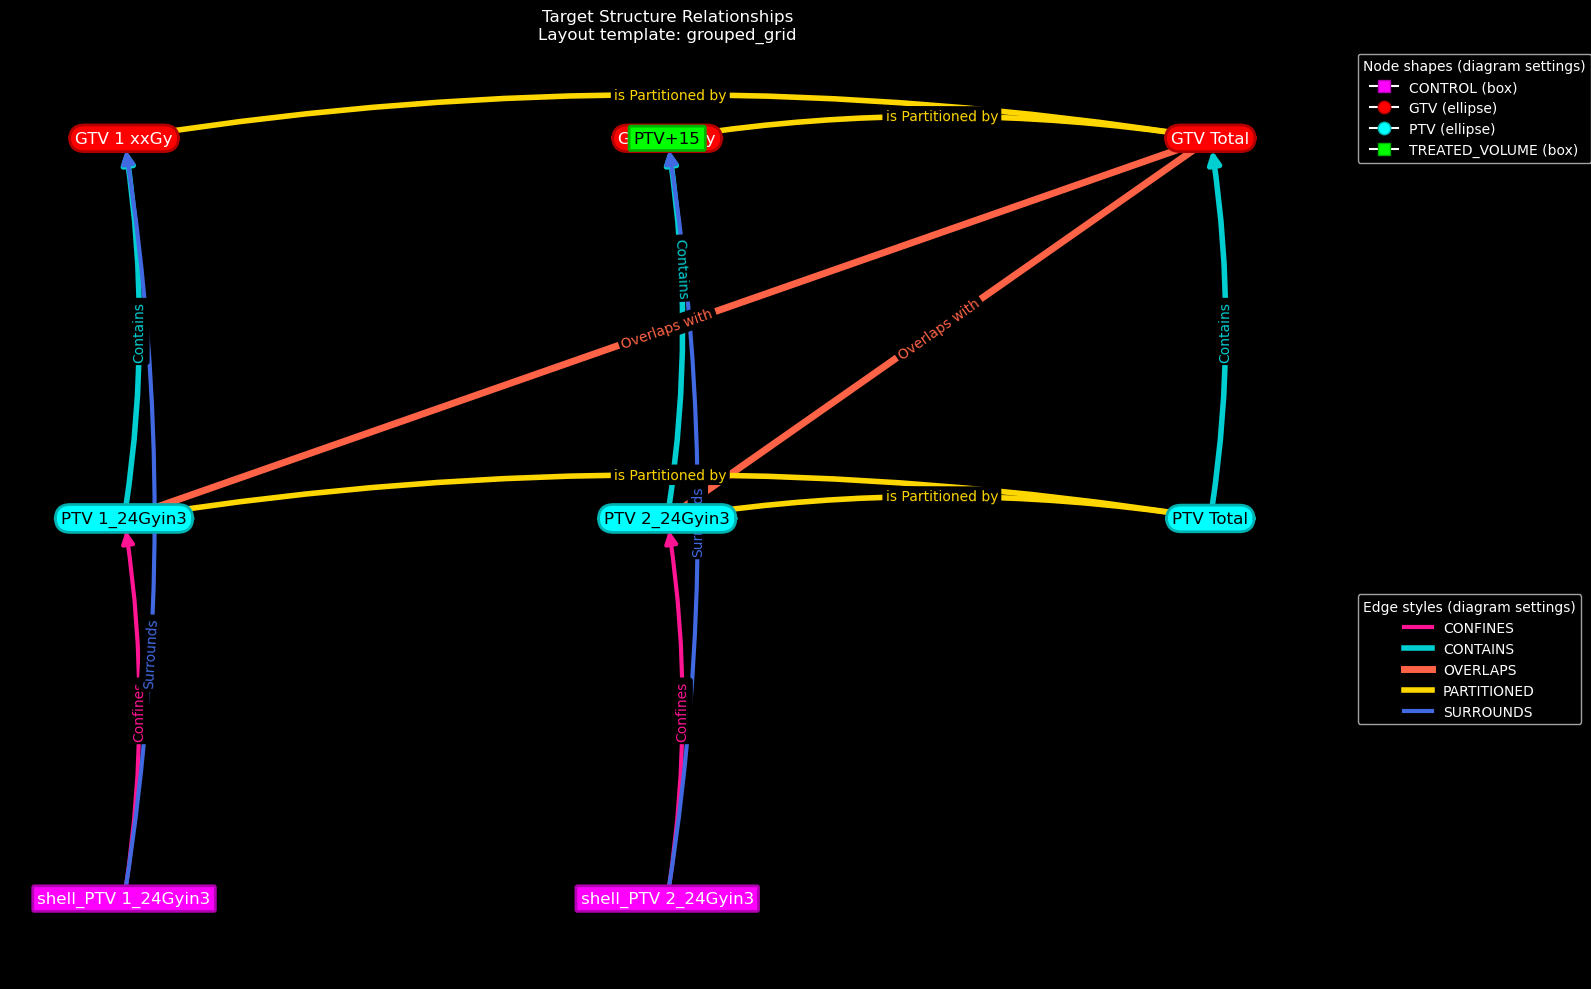

In [16]:
layout_template = default_grouped_grid_template()

module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)

metadata_preview = structure_set.structure_metadata.head()
original_filter_preview = structure_set.structure_filter_report[
    ['Structure ID', 'SelectedByDefault', 'DisplayedByDefault']
].head()

template_display_preview = module_result.display_report[
    [
        'Structure ID',
        'SelectedByDefault',
        'DisplayedByDefault',
        'TemplateFinalMatch',
    ]

].head()

layout_summary = {
    'template': module_result.layout_template_name,
    'positions': module_result.positions,
}

layout_summary

# display(module_result.fig)

## Load an example H&N DICOM structure set

In [21]:
dcm_file_name = 'RS.OROP2_3_dose_levels.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

# Use the structure filter rules to determine which structures to load.
filter_report = dicom_file.evaluate_structure_filters()
include_structures = list(filter_report.loc[filter_report['SelectedByDefault'],
                                            'Structure ID'])
structures_df = analyze_structure_grouping(dicom_file, apply_filter=True)

structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)

INFO:dicom:Successfully loaded DICOM dataset from RS.OROP2_3_dose_levels.dcm
INFO:dicom:Extracted 2371 contours from 52 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.OROP2_3_dose_levels.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.050 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.OROP2_3_dose_levels.dcm"),
 'PatientID': 'HN_OROP2',
 'PatientLastName': 'HN_OROP',
 'PatientName': 'HN_OROP^2Dose^Levels',
 'SeriesDescription': '',
 'SeriesNumber': 'None',
 'StructureSet': 'OROP',
 'StudyID': ''}


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


Add a sub level horizontal grouping for "TargetLaterality" then another sub level vertical grouping for "TargetSubGroup"

Also need to add a sug group for Mod (opt, eval ...)

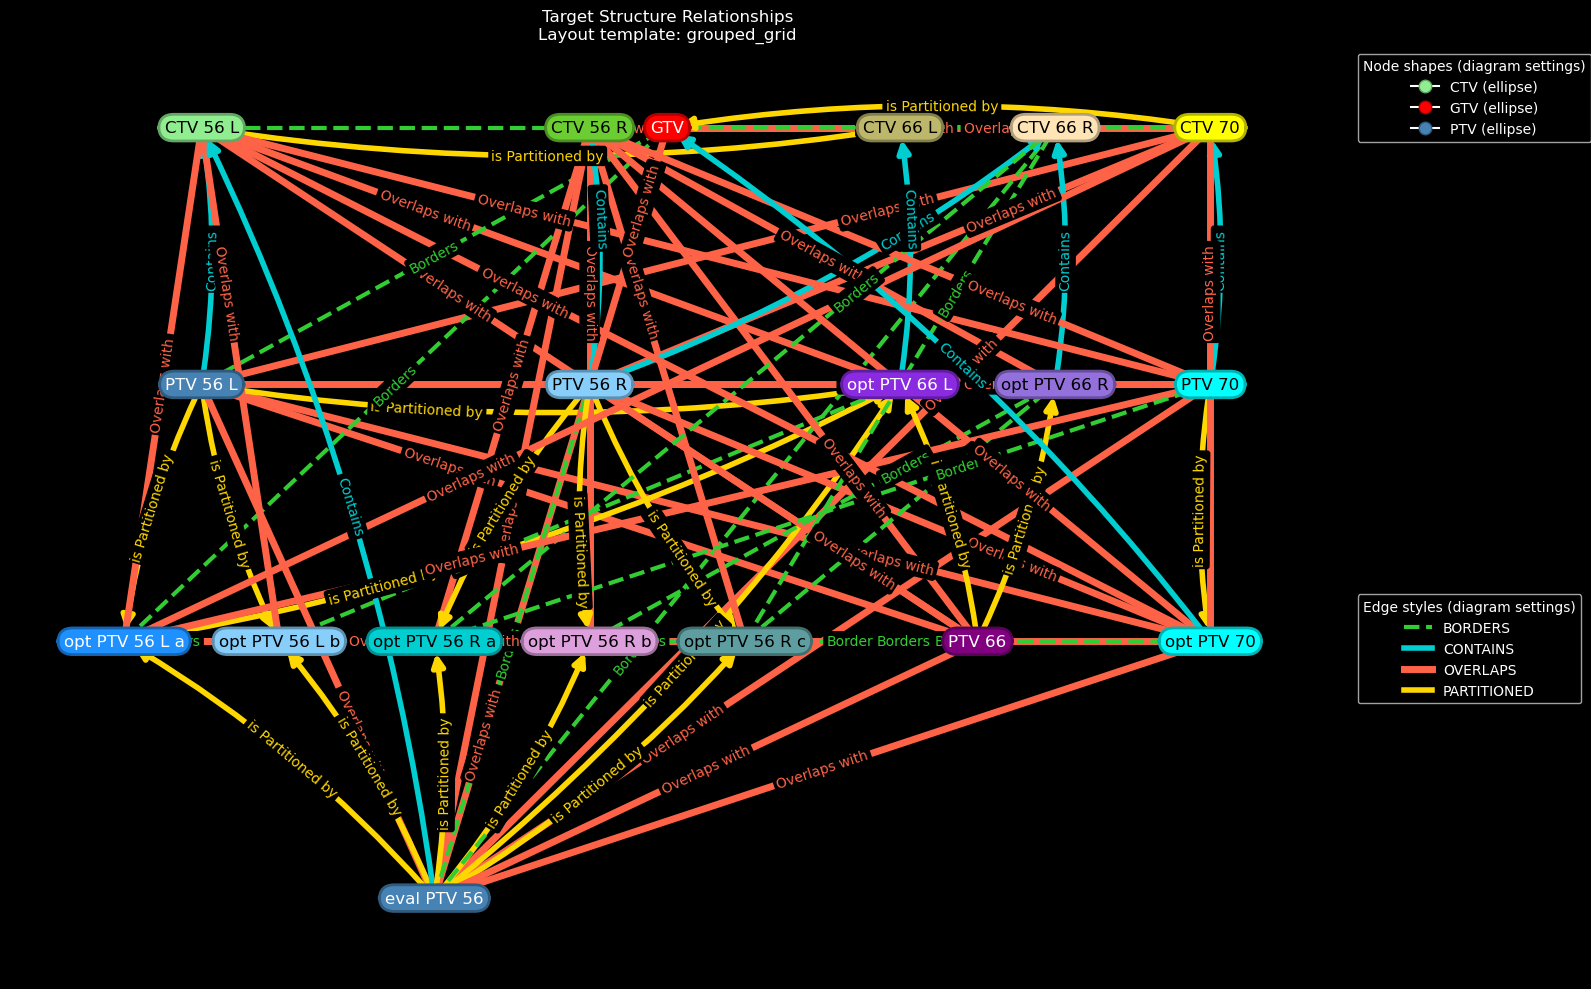

In [22]:
layout_template = get_layout_template('grouped_grid')
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)


## Target-OAR Template

This section exercises the new framework-backed `target_oar` template through the same registry and renderer path as the existing built-in templates.

('target_oar',
     ROI           Name   Structure ID DICOM Type node_side  display_order  \
 0    92       Mandible       Mandible      ORGAN       oar            0.0   
 1    68    eval PTV 56    eval PTV 56        PTV    target            0.0   
 2   101      Parotid B      Parotid B      ORGAN       oar            1.0   
 3    66         PTV 66         PTV 66        PTV    target            1.0   
 4   103      Parotid R      Parotid R      ORGAN       oar            2.0   
 5    79     opt PTV 70     opt PTV 70        PTV    target            2.0   
 6   114  opt Parotid R  opt Parotid R  AVOIDANCE       opt            2.5   
 7    88         Larynx         Larynx      ORGAN       oar            3.0   
 8   112     opt Larynx     opt Larynx  AVOIDANCE       opt            3.5   
 9   102      Parotid L      Parotid L      ORGAN       oar            4.0   
 10  113  opt Parotid L  opt Parotid L  AVOIDANCE       opt            4.5   
 
     weighted_oar_score  anchor_oar_roi  opt_ne

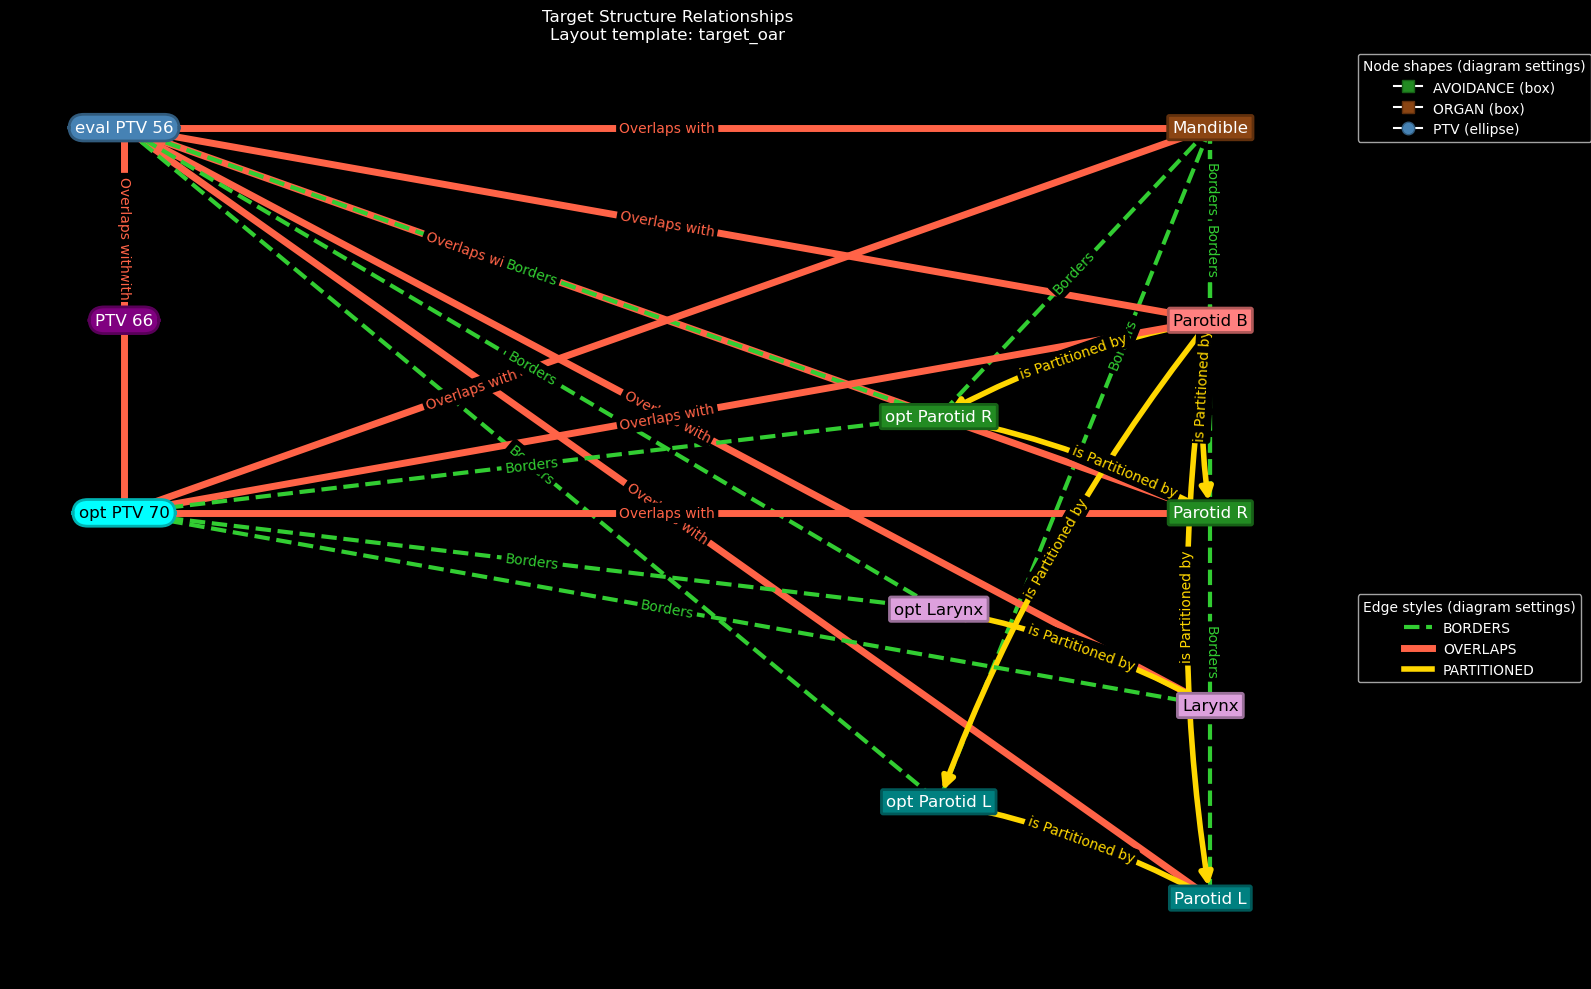

In [23]:
layout_template = get_layout_template('target_oar')
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)

target_oar_preview_columns = [
    'ROI',
    'Name',
    'Structure ID',
    'DICOM Type',
    'node_side',
    'display_order',
    'weighted_oar_score',
    'anchor_oar_roi',
    'opt_neighbor_oar_roi',
]
target_oar_preview_columns = [
    column
    for column in target_oar_preview_columns
    if column in module_result.plot_nodes.columns
]

module_result.layout_template_name, module_result.plot_nodes[target_oar_preview_columns]